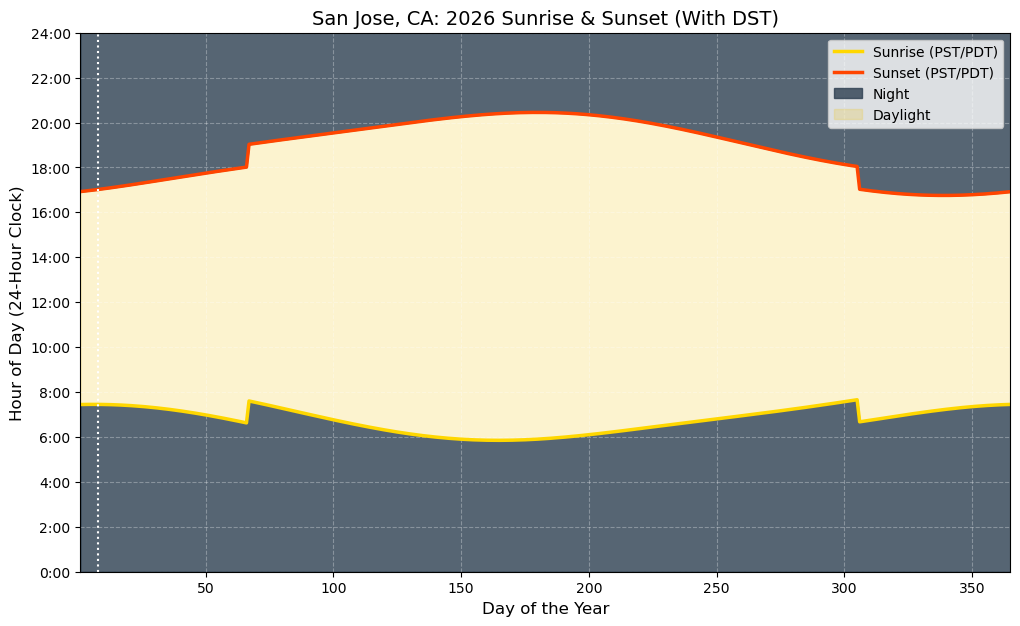

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date

def get_sj_times():
    days = np.arange(1, 366)
    lat = np.radians(37.33)  # San Jose Latitude
    lon = 121.88             # San Jose Longitude
    
    # 1. Standard Solar Math
    # Declination: angle of sun relative to equator
    delta = np.radians(23.44 * np.sin(np.radians(360/365 * (days - 81))))
    
    # Equation of Time: correction for Earth's orbital speed
    b = np.radians(360/364 * (days - 81))
    eot = 9.87 * np.sin(2*b) - 7.53 * np.cos(b) - 1.5 * np.sin(b)
    
    # Hour Angle
    cos_h = -np.tan(lat) * np.tan(delta)
    h = np.degrees(np.arccos(np.clip(cos_h, -1, 1)))
    
    # Solar Noon (Correction for SJ being west of the 120W meridian)
    lon_corr = 4 * (120 - lon) 
    solar_noon = (720 - lon_corr - eot) / 60
    
    sunrise = solar_noon - (h / 15)
    sunset = solar_noon + (h / 15)
    
    # 2. Add Daylight Savings Time (DST) Logic for 2026
    # DST starts March 8 (Day 67) and ends Nov 1 (Day 305)
    dst_mask = (days >= 67) & (days <= 305)
    sunrise[dst_mask] += 1
    sunset[dst_mask] += 1
    
    return days, sunrise, sunset

days, sunrise, sunset = get_sj_times()

# --- Visualization ---
plt.figure(figsize=(12, 7))
plt.plot(days, sunrise, color='#FFD700', label='Sunrise (PST/PDT)', linewidth=2.5)
plt.plot(days, sunset, color='#FF4500', label='Sunset (PST/PDT)', linewidth=2.5)

# Fill the night areas
plt.fill_between(days, 0, sunrise, color='#2c3e50', alpha=0.8, label='Night')
plt.fill_between(days, sunset, 24, color='#2c3e50', alpha=0.8)
plt.fill_between(days, sunrise, sunset, color='#f1c40f', alpha=0.2, label='Daylight')

# Aesthetics
plt.title("San Jose, CA: 2026 Sunrise & Sunset (With DST)", fontsize=14)
plt.ylabel("Hour of Day (24-Hour Clock)", fontsize=12)
plt.xlabel("Day of the Year", fontsize=12)
plt.yticks(range(0, 25, 2), [f"{i}:00" for i in range(0, 25, 2)])
plt.grid(color='white', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True)
plt.xlim(1, 365)
plt.ylim(0, 24)

# Highlight Today (January 8)
plt.axvline(8, color='white', linestyle=':', label='Today')

plt.show()